In [5]:
import pandas as pd

df = pd.read_csv("../data/raw/raid_samples.csv")
print(df["label"].value_counts())

label
Risk          20
Assumption    20
Dependency    20
Decision      20
Other         20
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7
              precision    recall  f1-score   support

  Assumption       0.50      0.50      0.50         4
    Decision       0.60      0.75      0.67         4
  Dependency       0.80      1.00      0.89         4
       Other       0.67      0.50      0.57         4
        Risk       1.00      0.75      0.86         4

    accuracy                           0.70        20
   macro avg       0.71      0.70      0.70        20
weighted avg       0.71      0.70      0.70        20



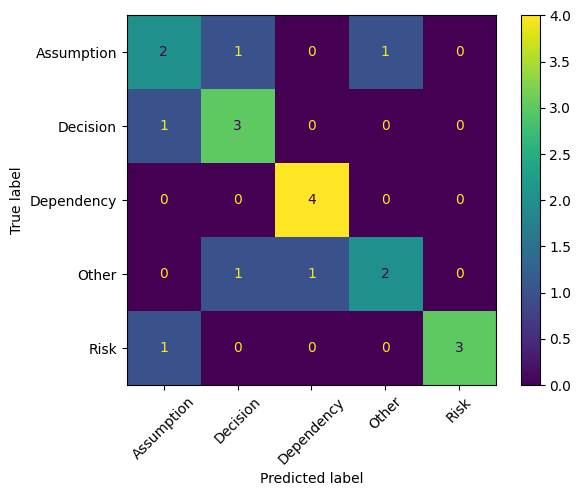

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, xticks_rotation=45)
plt.show()